# Oráculo: calibración de reflectividad

Oráculo de `docs/algorithms/reflectivity-calibration.md`, independiente de
cualquier crate Rust (todavía no existe implementación de este algoritmo — es
el primer paso del método de `docs/algorithms/roadmap.md` §"Método de
estudio").

La página describe una cadena de *procedimiento*, no un estimador con
fórmula propia: el DSP **aplica** `radar_constant_db`, `receiver_gain_db` y
`noise_floor_dbm`, no los determina. Lo que sí es responsabilidad del DSP —y
lo único con contenido numérico verificable en simulación— es la ecuación del
radar meteorológico en su forma logarítmica estándar (Doviak & Zrnić 1993,
cap. 4):

```
dBZ = 10·log10(S_lineal) + 20·log10(rango_km / rango_ref_km) + radar_constant_db
```

con `S_lineal` la potencia de señal ya libre de ruido (oráculo de
`ruido-y-umbrales.md`). Este notebook comprueba dos cosas, tal como pide el
criterio de aceptación de la página:

1. **Corrección por r²**: para un blanco de reflectividad verdadera fija, la
   ecuación debe recuperar la misma Z sin importar el rango, celda a celda.
2. **Linealidad en todo el rango dinámico**: para un rango fijo, barriendo la
   potencia inyectada desde cerca del piso de ruido hasta señal fuerte, la Z
   publicada debe seguir linealmente (pendiente 1, sin desvío sistemático) a
   la Z inyectada — el equivalente en simulación al procedimiento de
   inyección de señal de prueba (*built-in test*) del sistema real.

El generador de I/Q y el estimador de ruido de Hildebrand & Sekhon se
reimplementan aquí sin cambios respecto al oráculo de `ruido-y-umbrales.md`
—mismo sesgo conocido de ~0.1-0.4 dB a `navg=1`, que aquí se hereda, no se
vuelve a investigar— para que el notebook sea autocontenido.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(20260902)
plt.rcParams["figure.figsize"] = (9, 4)
np.set_printoptions(precision=4, suppress=True)

In [2]:
def gaussian_doppler_spectrum(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, wrap=3):
    v_a = wavelength_m / (4.0 * prt_s)
    f_k = np.fft.fftfreq(m, d=prt_s)
    v_k = f_k * wavelength_m / 2.0
    n = np.arange(-wrap, wrap + 1)
    dv = v_k[:, None] - mean_v - n[None, :] * 2.0 * v_a
    acc = np.exp(-0.5 * (dv / sigma_v) ** 2).sum(axis=1)
    return power_s * acc / acc.sum()


def complex_gaussian(rng, variance, size=None):
    sigma = np.sqrt(variance / 2.0)
    return rng.normal(0.0, sigma, size=size) + 1j * rng.normal(0.0, sigma, size=size)


def generate_cell(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, noise_floor, rng, wrap=3):
    spectrum = gaussian_doppler_spectrum(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, wrap)
    w = complex_gaussian(rng, 1.0, size=m)
    shaped = w * np.sqrt(spectrum)
    y = np.fft.ifft(shaped) * m
    if noise_floor > 0.0:
        y = y + complex_gaussian(rng, noise_floor, size=m)
    return y


def periodogram(y):
    m = len(y)
    yf = np.fft.fft(y)
    return (np.abs(yf) ** 2) / (m ** 2)


def hildebrand_sekhon(p, navg=1):
    """Ecuación 9 de Hildebrand & Sekhon (1974), verificada contra
    pyart.util.hildebrand_sekhon.estimate_noise_hs74 — ver el oráculo de
    ruido-y-umbrales.md para la derivación y el sesgo conocido."""
    p_sorted = np.sort(p)
    n = len(p_sorted)
    rtest = 1.0 + 1.0 / navg
    nnoise = n
    sum1 = 0.0
    sum2 = 0.0
    for i in range(n):
        pwr = p_sorted[i]
        npts = i + 1
        sum1 += pwr
        sum2 += pwr * pwr
        if npts * sum2 < sum1 * sum1 * rtest:
            nnoise = npts
        else:
            sum1 -= pwr
            sum2 -= pwr * pwr
            break
    return sum1 / nnoise


def noise_floor_estimate(y):
    m = len(y)
    return hildebrand_sekhon(periodogram(y)) * m


def estimate_linear_power(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, noise_floor, rng):
    """S_hat = max(R(0) - N_HS74, 0) de una única ráfaga simulada."""
    y = generate_cell(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, noise_floor, rng)
    r0_hat = np.mean(np.abs(y) ** 2)
    n_hat = noise_floor_estimate(y)
    return max(r0_hat - n_hat, 0.0)

## Ecuación del radar y su inversa

`RADAR_CONSTANT_DB` y `RANGE_REF_KM` son valores de configuración ilustrativos
para este escenario de prueba —el contrato los trata como parámetros que el
DSP aplica, no como constantes físicas fijas— elegidos para que la potencia
resultante quede muy por encima del piso de ruido en la prueba de r² (aislar
la corrección de rango del sesgo de Hildebrand & Sekhon, que ya se cuantificó
en el oráculo de ruido) y para cubrir un rango dinámico realista en la prueba
de linealidad.

In [3]:
RADAR_CONSTANT_DB = -40.0
RANGE_REF_KM = 1.0
NOISE_FLOOR = 0.05
MEAN_V, SIGMA_V, WAVELENGTH_M, PRT_S, M = 5.0, 1.5, 0.10, 1.0e-3, 256


def power_to_dbz(s_linear, range_km):
    return 10.0 * np.log10(s_linear) + 20.0 * np.log10(range_km / RANGE_REF_KM) + RADAR_CONSTANT_DB


def dbz_to_power(dbz, range_km):
    return 10.0 ** ((dbz - RADAR_CONSTANT_DB - 20.0 * np.log10(range_km / RANGE_REF_KM)) / 10.0)


checks = []

## Prueba 1 — corrección por r²

Un blanco de reflectividad verdadera fija `Z_TRUE` debe recuperarse igual a
cualquier rango: la potencia recibida cae como `1/r²` (radar equation), y la
corrección `+20·log10(r)` debe compensarlo exactamente. Se elige `Z_TRUE` y
`NOISE_FLOOR` para que la SNR sea alta incluso al rango más lejano — así el
residuo medido es sólo el sesgo conocido del estimador de ruido, no un efecto
de SNR baja, y cualquier fuga dependiente del rango señala un error real en
la corrección de r².

rango=   5.0 km  SNR= 69.03 dB  dBZ_hat= 29.938  sesgo=-0.062 dB


rango=  20.0 km  SNR= 56.99 dB  dBZ_hat= 29.924  sesgo=-0.076 dB


rango=  50.0 km  SNR= 49.03 dB  dBZ_hat= 29.961  sesgo=-0.039 dB


rango= 100.0 km  SNR= 43.01 dB  dBZ_hat= 29.965  sesgo=-0.035 dB


rango= 150.0 km  SNR= 39.49 dB  dBZ_hat= 29.884  sesgo=-0.116 dB


rango= 200.0 km  SNR= 36.99 dB  dBZ_hat= 29.910  sesgo=-0.090 dB


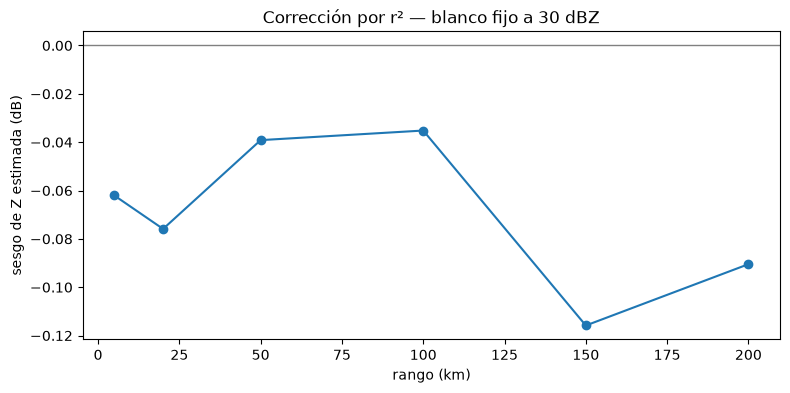

In [4]:
Z_TRUE = 30.0
RANGE_GRID_KM = np.array([5.0, 20.0, 50.0, 100.0, 150.0, 200.0])
N_TRIALS_RANGE = 800
RANGE_BIAS_TOLERANCE_DB = 0.5

dbz_hat_by_range = np.zeros_like(RANGE_GRID_KM)
snr_db_by_range = np.zeros_like(RANGE_GRID_KM)

for i, range_km in enumerate(RANGE_GRID_KM):
    power_s = dbz_to_power(Z_TRUE, range_km)
    snr_db_by_range[i] = 10.0 * np.log10(power_s / NOISE_FLOOR)
    estimates = [
        power_to_dbz(
            estimate_linear_power(power_s, MEAN_V, SIGMA_V, WAVELENGTH_M, PRT_S, M, NOISE_FLOOR, rng),
            range_km,
        )
        for _ in range(N_TRIALS_RANGE)
    ]
    dbz_hat_by_range[i] = np.mean(estimates)
    print(f"rango={range_km:6.1f} km  SNR={snr_db_by_range[i]:6.2f} dB  "
          f"dBZ_hat={dbz_hat_by_range[i]:7.3f}  sesgo={dbz_hat_by_range[i] - Z_TRUE:+.3f} dB")

fig, ax = plt.subplots()
ax.plot(RANGE_GRID_KM, dbz_hat_by_range - Z_TRUE, marker="o")
ax.axhline(0.0, color="gray", linewidth=1)
ax.set_xlabel("rango (km)")
ax.set_ylabel("sesgo de Z estimada (dB)")
ax.set_title(f"Corrección por r² — blanco fijo a {Z_TRUE:.0f} dBZ")
plt.show()

range_bias_ok = np.all(np.abs(dbz_hat_by_range - Z_TRUE) < RANGE_BIAS_TOLERANCE_DB)
checks.append((f"Z recuperada dentro de {RANGE_BIAS_TOLERANCE_DB} dB a lo largo de todo el alcance "
               f"({RANGE_GRID_KM.min():.0f}-{RANGE_GRID_KM.max():.0f} km)", range_bias_ok))

## Prueba 2 — linealidad en todo el rango dinámico

A rango fijo, se barre la potencia inyectada desde cerca del piso de ruido
(SNR ≈ −6 dB) hasta señal fuerte (SNR ≈ 38 dB) — el equivalente en simulación
de barrer la potencia del generador de señal de prueba en una verificación de
banco. Se ajusta una recta `dBZ_hat` frente a `dBZ_true` sobre los puntos con
SNR ≥ 0 dB (por debajo de ese punto domina la censura por `S_hat == 0`, que es
comportamiento esperado, no una prueba de linealidad) y se exige pendiente ≈ 1
y desviación acotada respecto de la recta teórica.

SNR=  -6.0 dB  dBZ_true=-19.010  dBZ_hat=-21.368  censuradas=0.8%


SNR=  -2.0 dB  dBZ_true=-15.010  dBZ_hat=-15.610  censuradas=0.0%


SNR=   2.0 dB  dBZ_true=-11.010  dBZ_hat=-11.221  censuradas=0.0%


SNR=   6.0 dB  dBZ_true= -7.010  dBZ_hat= -7.110  censuradas=0.0%


SNR=  10.0 dB  dBZ_true= -3.010  dBZ_hat= -3.123  censuradas=0.0%


...

SNR=  22.0 dB  dBZ_true=  8.990  dBZ_hat=  8.958  censuradas=0.0%


SNR=  26.0 dB  dBZ_true= 12.990  dBZ_hat= 12.973  censuradas=0.0%


SNR=  30.0 dB  dBZ_true= 16.990  dBZ_hat= 16.908  censuradas=0.0%


SNR=  34.0 dB  dBZ_true= 20.990  dBZ_hat= 20.918  censuradas=0.0%


SNR=  38.0 dB  dBZ_true= 24.990  dBZ_hat= 24.931  censuradas=0.0%


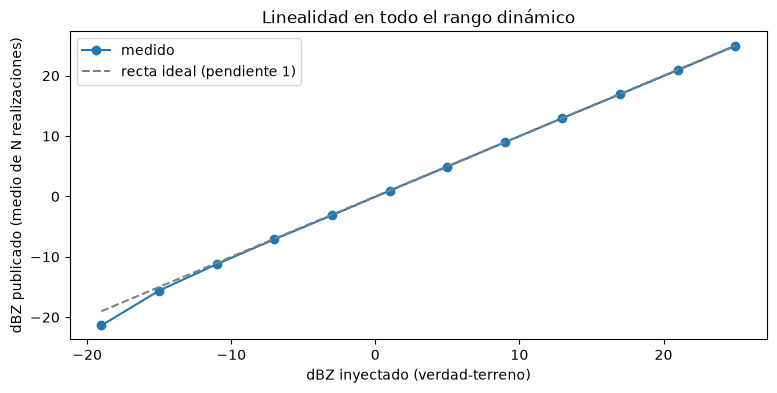


ajuste sobre SNR>=0 dB: pendiente=1.0028  intercepto=-0.100 dB  máximo residuo=0.080 dB


In [5]:
RANGE_KM_FOR_LINEARITY = 100.0
SNR_DB_GRID = np.arange(-6.0, 42.0, 4.0)
N_TRIALS_LINEARITY = 800
SLOPE_TOLERANCE = 0.02
RESIDUAL_TOLERANCE_DB = 0.5

injected_power = NOISE_FLOOR * 10.0 ** (SNR_DB_GRID / 10.0)
dbz_true_grid = np.array([power_to_dbz(p, RANGE_KM_FOR_LINEARITY) for p in injected_power])
dbz_hat_grid = np.full_like(dbz_true_grid, np.nan)
censored_frac = np.zeros_like(dbz_true_grid)

for i, power_s in enumerate(injected_power):
    estimates = []
    n_censored = 0
    for _ in range(N_TRIALS_LINEARITY):
        s_hat = estimate_linear_power(power_s, MEAN_V, SIGMA_V, WAVELENGTH_M, PRT_S, M, NOISE_FLOOR, rng)
        if s_hat > 0.0:
            estimates.append(power_to_dbz(s_hat, RANGE_KM_FOR_LINEARITY))
        else:
            n_censored += 1
    censored_frac[i] = n_censored / N_TRIALS_LINEARITY
    if estimates:
        dbz_hat_grid[i] = np.mean(estimates)
    print(f"SNR={SNR_DB_GRID[i]:6.1f} dB  dBZ_true={dbz_true_grid[i]:7.3f}  "
          f"dBZ_hat={dbz_hat_grid[i]:7.3f}  censuradas={censored_frac[i]:.1%}")

fig, ax = plt.subplots()
ax.plot(dbz_true_grid, dbz_hat_grid, marker="o", label="medido")
ax.plot(dbz_true_grid, dbz_true_grid, linestyle="--", color="gray", label="recta ideal (pendiente 1)")
ax.set_xlabel("dBZ inyectado (verdad-terreno)")
ax.set_ylabel("dBZ publicado (medio de N realizaciones)")
ax.set_title("Linealidad en todo el rango dinámico")
ax.legend()
plt.show()

fit_mask = (SNR_DB_GRID >= 0.0) & np.isfinite(dbz_hat_grid)
slope, intercept = np.polyfit(dbz_true_grid[fit_mask], dbz_hat_grid[fit_mask], 1)
residuals = dbz_hat_grid[fit_mask] - (slope * dbz_true_grid[fit_mask] + intercept)
max_residual = np.max(np.abs(residuals))
print(f"\najuste sobre SNR>=0 dB: pendiente={slope:.4f}  intercepto={intercept:+.3f} dB  "
      f"máximo residuo={max_residual:.3f} dB")

checks.append((f"pendiente de linealidad dentro de {SLOPE_TOLERANCE} de 1.0", abs(slope - 1.0) < SLOPE_TOLERANCE))
checks.append((f"residuo máximo respecto de la recta teórica < {RESIDUAL_TOLERANCE_DB} dB", max_residual < RESIDUAL_TOLERANCE_DB))

In [6]:
all_ok = True
for name, ok in checks:
    print(f"[{'OK' if ok else 'FALLO'}] {name}")
    all_ok = all_ok and ok

assert all_ok, "el oráculo de calibración de reflectividad no pasa todas las comprobaciones — ver tabla arriba"
print("\nTodas las comprobaciones dentro de tolerancia.")

[OK] Z recuperada dentro de 0.5 dB a lo largo de todo el alcance (5-200 km)
[OK] pendiente de linealidad dentro de 0.02 de 1.0
[OK] residuo máximo respecto de la recta teórica < 0.5 dB

Todas las comprobaciones dentro de tolerancia.
